In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pwd

'c:\\Users\\DELL\\OneDrive\\Documentos\\GitHub\\Prison_Management\\ai_service\\training\\Predict'

In [3]:
df = pd.read_csv("recidivism_score.csv")
df.head()

,Age,Gender,Sentence Type,education_level,Sentence_duration_months,Incident_count,violent_incidents_count,escape_incidents_count,Recidivism_score
0,58,Male,Kidnapping,Primary,155,12,1,2,70.0
1,65,Male,Kidnapping,Secondary,271,8,2,1,55.8
2,45,Male,Theft,Primary,41,16,3,4,83.3
3,19,Male,Sexual Offense,Secondary,203,10,3,3,94.3
4,32,Male,Robbery,Bachelor's,133,9,2,1,54.4


In [4]:
df.tail()


,Age,Gender,Sentence Type,education_level,Sentence_duration_months,Incident_count,violent_incidents_count,escape_incidents_count,Recidivism_score
19995,35,Male,Assault,Primary,57,10,2,1,60.9
19996,27,Male,Arson,Secondary,116,12,5,3,81.7
19997,60,Male,Theft,Secondary,35,12,1,3,49.5
19998,34,Male,Assault,Preparatory,49,13,2,2,77.5
19999,54,Male,Robbery,Secondary,136,12,4,0,54.7


In [5]:
df.shape

(20000, 9)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       20000 non-null  int64  
 1   Gender                    20000 non-null  str    
 2   Sentence Type             20000 non-null  str    
 3   education_level           20000 non-null  str    
 4   Sentence_duration_months  20000 non-null  int64  
 5   Incident_count            20000 non-null  int64  
 6   violent_incidents_count   20000 non-null  int64  
 7   escape_incidents_count    20000 non-null  int64  
 8   Recidivism_score          20000 non-null  float64
dtypes: float64(1), int64(5), str(3)
memory usage: 1.4 MB


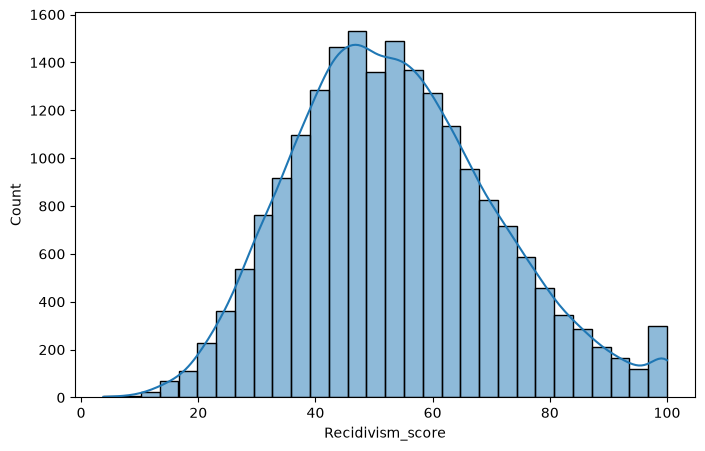

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Recidivism_score"],
    bins=30,
    kde=True
)

plt.show()

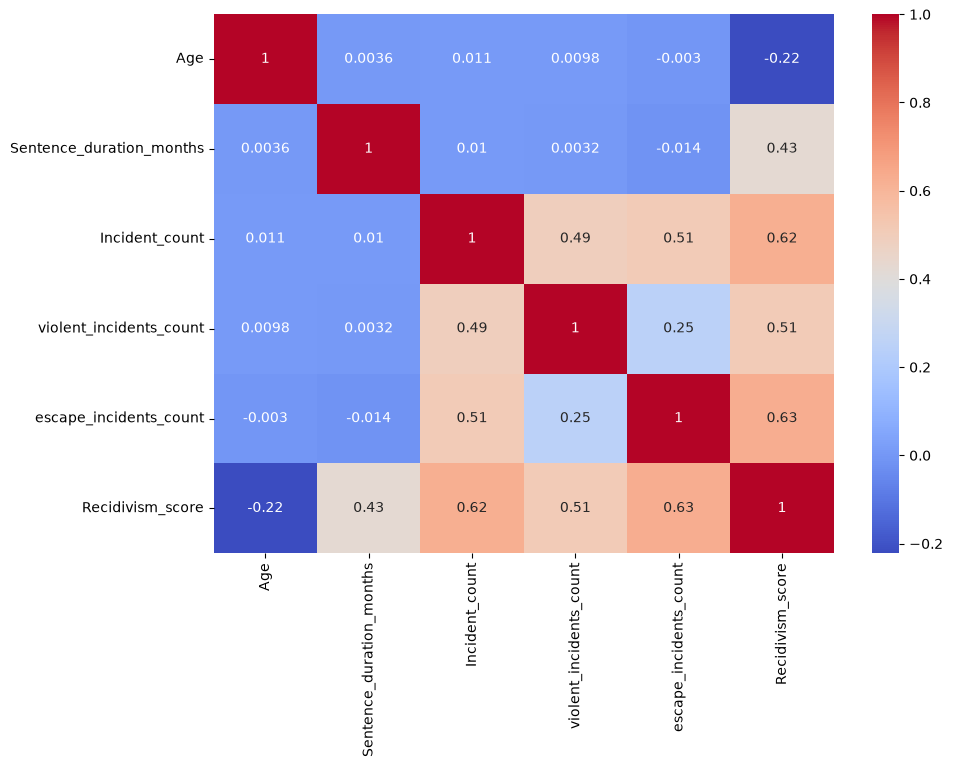

In [8]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [9]:
from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()

df["Gender"] = le_gender.fit_transform(df["Gender"])

In [10]:
education_order = {
    "Illiterate": 0,
    "Literate": 1,
    "Primary": 2,
    "Preparatory": 3,
    "Secondary": 4,
    "Bachelor's": 5,
    "Postgraduate education": 6
}

df["education_level"] = df["education_level"].map(education_order)

In [11]:
df = pd.get_dummies(
    df,
    columns=["Sentence Type"],
    drop_first=True,
    dtype=int
)

In [12]:
df.head()

,Age,Gender,education_level,Sentence_duration_months,Incident_count,violent_incidents_count,escape_incidents_count,Recidivism_score,Sentence Type_Assault,Sentence Type_Burglary,...,Sentence Type_Drug Offense,Sentence Type_Fraud,Sentence Type_Kidnapping,Sentence Type_Murder,Sentence Type_Public Order,Sentence Type_Robbery,Sentence Type_Sexual Offense,Sentence Type_Theft,Sentence Type_Vandalism,Sentence Type_Weapons Offense
0,58,1,2,155,12,1,2,70.0,0,0,...,0,0,1,0,0,0,0,0,0,0
1,65,1,4,271,8,2,1,55.8,0,0,...,0,0,1,0,0,0,0,0,0,0
2,45,1,2,41,16,3,4,83.3,0,0,...,0,0,0,0,0,0,0,1,0,0
3,19,1,4,203,10,3,3,94.3,0,0,...,0,0,0,0,0,0,1,0,0,0
4,32,1,5,133,9,2,1,54.4,0,0,...,0,0,0,0,0,1,0,0,0,0


In [13]:
X = df.drop(
    "Recidivism_score",
    axis=1
)

y = df["Recidivism_score"]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42
)

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    median_absolute_error,
    explained_variance_score
)

import numpy as np

In [16]:
results = []

# Train
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

n = len(y_test)
p = X_test.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)

mape = mean_absolute_percentage_error(y_test, y_pred) * 100
medae = median_absolute_error(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)

# Save Results
results.append({
    "Model": "Linear Regression",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R² Score": r2,
    "Adjusted R²": adjusted_r2,
    "MAPE (%)": mape,
    "Median AE": medae,
    "Explained Variance": evs
})

# Show Metrics
pd.DataFrame(results)

,Model,MAE,MSE,RMSE,R² Score,Adjusted R²,MAPE (%),Median AE,Explained Variance
0,Linear Regression,3.418596,18.194512,4.265503,0.93868,0.938372,7.205707,2.885819,0.938688


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
from sklearn.neural_network import MLPRegressor

# Train
model = MLPRegressor(
    hidden_layer_sizes=(100,),
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

n = len(y_test)
p = X_test.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)

mape = mean_absolute_percentage_error(y_test, y_pred) * 100
medae = median_absolute_error(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)

# Save Results
results.append({
    "Model": "Neural Network",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R² Score": r2,
    "Adjusted R²": adjusted_r2,
    "MAPE (%)": mape,
    "Median AE": medae,
    "Explained Variance": evs
})

pd.DataFrame(results)

,Model,MAE,MSE,RMSE,R² Score,Adjusted R²,MAPE (%),Median AE,Explained Variance
0,Linear Regression,3.418596,18.194512,4.265503,0.938680,0.938372,7.205707,2.885819,0.938688
1,Neural Network,3.395319,17.961636,4.238117,0.939465,0.939161,7.189056,2.888919,0.939469


In [19]:
from sklearn.svm import SVR

# Train
model = SVR()

model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

n = len(y_test)
p = X_test.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)

mape = mean_absolute_percentage_error(y_test, y_pred) * 100
medae = median_absolute_error(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)

# Save Results
results.append({
    "Model": "SVR",
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse,
    "R² Score": r2,
    "Adjusted R²": adjusted_r2,
    "MAPE (%)": mape,
    "Median AE": medae,
    "Explained Variance": evs
})

pd.DataFrame(results)

,Model,MAE,MSE,RMSE,R² Score,Adjusted R²,MAPE (%),Median AE,Explained Variance
0,Linear Regression,3.418596,18.194512,4.265503,0.938680,0.938372,7.205707,2.885819,0.938688
1,Neural Network,3.395319,17.961636,4.238117,0.939465,0.939161,7.189056,2.888919,0.939469
2,SVR,3.593992,20.406161,4.517318,0.931226,0.930881,7.677888,2.999792,0.931231


In [20]:
from sklearn.tree import DecisionTreeRegressor

# Train
model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

n = len(y_test)
p = X_test.shape[1]

adjusted_r2 = 1 - ((1-r2)*(n-1))/(n-p-1)

mape = mean_absolute_percentage_error(y_test, y_pred) * 100
medae = median_absolute_error(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)

results.append({
    "Model":"Decision Tree",
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse,
    "R² Score":r2,
    "Adjusted R²":adjusted_r2,
    "MAPE (%)":mape,
    "Median AE":medae,
    "Explained Variance":evs
})

pd.DataFrame(results)

,Model,MAE,MSE,RMSE,R² Score,Adjusted R²,MAPE (%),Median AE,Explained Variance
0,Linear Regression,3.418596,18.194512,4.265503,0.938680,0.938372,7.205707,2.885819,0.938688
1,Neural Network,3.395319,17.961636,4.238117,0.939465,0.939161,7.189056,2.888919,0.939469
2,SVR,3.593992,20.406161,4.517318,0.931226,0.930881,7.677888,2.999792,0.931231
3,Decision Tree,5.636051,50.252537,7.088902,0.830637,0.829786,11.846428,4.869123,0.830637


In [21]:
from sklearn.ensemble import RandomForestRegressor

# Train
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

n = len(y_test)
p = X_test.shape[1]

adjusted_r2 = 1 - ((1-r2)*(n-1))/(n-p-1)

mape = mean_absolute_percentage_error(y_test, y_pred) * 100
medae = median_absolute_error(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)

results.append({
    "Model":"Random Forest",
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse,
    "R² Score":r2,
    "Adjusted R²":adjusted_r2,
    "MAPE (%)":mape,
    "Median AE":medae,
    "Explained Variance":evs
})

pd.DataFrame(results)

,Model,MAE,MSE,RMSE,R² Score,Adjusted R²,MAPE (%),Median AE,Explained Variance
0,Linear Regression,3.418596,18.194512,4.265503,0.938680,0.938372,7.205707,2.885819,0.938688
1,Neural Network,3.395319,17.961636,4.238117,0.939465,0.939161,7.189056,2.888919,0.939469
2,SVR,3.593992,20.406161,4.517318,0.931226,0.930881,7.677888,2.999792,0.931231
3,Decision Tree,5.636051,50.252537,7.088902,0.830637,0.829786,11.846428,4.869123,0.830637
4,Random Forest,3.953522,24.700939,4.970004,0.916752,0.916334,8.307769,3.337333,0.916776


In [22]:
from sklearn.ensemble import GradientBoostingRegressor

# Train
model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

n = len(y_test)
p = X_test.shape[1]

adjusted_r2 = 1 - ((1-r2)*(n-1))/(n-p-1)

mape = mean_absolute_percentage_error(y_test, y_pred) * 100
medae = median_absolute_error(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)

results.append({
    "Model":"GBDT",
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse,
    "R² Score":r2,
    "Adjusted R²":adjusted_r2,
    "MAPE (%)":mape,
    "Median AE":medae,
    "Explained Variance":evs
})

pd.DataFrame(results)

,Model,MAE,MSE,RMSE,R² Score,Adjusted R²,MAPE (%),Median AE,Explained Variance
0,Linear Regression,3.418596,18.194512,4.265503,0.938680,0.938372,7.205707,2.885819,0.938688
1,Neural Network,3.395319,17.961636,4.238117,0.939465,0.939161,7.189056,2.888919,0.939469
2,SVR,3.593992,20.406161,4.517318,0.931226,0.930881,7.677888,2.999792,0.931231
3,Decision Tree,5.636051,50.252537,7.088902,0.830637,0.829786,11.846428,4.869123,0.830637
4,Random Forest,3.953522,24.700939,4.970004,0.916752,0.916334,8.307769,3.337333,0.916776
5,GBDT,3.370833,17.798324,4.218806,0.940015,0.939714,7.145927,2.836752,0.940016


In [23]:
from xgboost import XGBRegressor

# Train
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

n = len(y_test)
p = X_test.shape[1]

adjusted_r2 = 1 - ((1-r2)*(n-1))/(n-p-1)

mape = mean_absolute_percentage_error(y_test, y_pred) * 100
medae = median_absolute_error(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)

results.append({
    "Model":"XGBoost",
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse,
    "R² Score":r2,
    "Adjusted R²":adjusted_r2,
    "MAPE (%)":mape,
    "Median AE":medae,
    "Explained Variance":evs
})

pd.DataFrame(results)

,Model,MAE,MSE,RMSE,R² Score,Adjusted R²,MAPE (%),Median AE,Explained Variance
0,Linear Regression,3.418596,18.194512,4.265503,0.938680,0.938372,7.205707,2.885819,0.938688
1,Neural Network,3.395319,17.961636,4.238117,0.939465,0.939161,7.189056,2.888919,0.939469
2,SVR,3.593992,20.406161,4.517318,0.931226,0.930881,7.677888,2.999792,0.931231
3,Decision Tree,5.636051,50.252537,7.088902,0.830637,0.829786,11.846428,4.869123,0.830637
4,Random Forest,3.953522,24.700939,4.970004,0.916752,0.916334,8.307769,3.337333,0.916776
5,GBDT,3.370833,17.798324,4.218806,0.940015,0.939714,7.145927,2.836752,0.940016
6,XGBoost,3.332500,17.325958,4.162446,0.941607,0.941314,7.078882,2.858577,0.941608


In [24]:
from sklearn.model_selection import cross_val_score

# Create the model
cv_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Cross Validation
scores = cross_val_score(
    cv_model,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Show Results
for i, score in enumerate(scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print("--------------------------------")
print(f"Average R² : {scores.mean():.4f}")
print(f"St.D        : {scores.std():.4f}")
print(f"Best Fold  : {scores.max():.4f}")
print(f"Worst Fold : {scores.min():.4f}")

Fold 1: 0.9398
Fold 2: 0.9415
Fold 3: 0.9410
Fold 4: 0.9420
Fold 5: 0.9353
--------------------------------
Average R² : 0.9399
St.D        : 0.0024
Best Fold  : 0.9420
Worst Fold : 0.9353


In [25]:
from sklearn.model_selection import RandomizedSearchCV

# Parameters
param_dist = {
    "n_estimators": [200, 300, 500, 700, 1000],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "max_depth": [3, 4, 5, 6, 7],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.2, 0.3]
}

random_search = RandomizedSearchCV(
    estimator=XGBRegressor(
        random_state=42
    ),
    param_distributions=param_dist,
    n_iter=20,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print(random_search.best_params_)


{'subsample': 0.8, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 0.8}


In [26]:
best_model = XGBRegressor(
    **random_search.best_params_,
    random_state=42
)

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print(r2)

0.9420842090698152


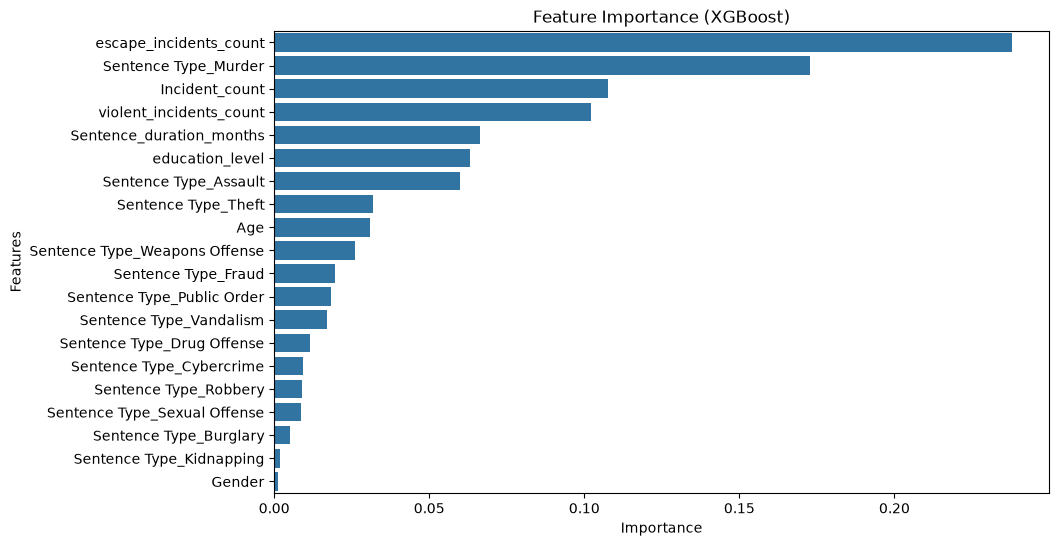

In [27]:
importance = best_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.show()

In [28]:
import joblib

joblib.dump(
    best_model,
    "recidivism_score_model.pkl"
)

['recidivism_score_model.pkl']

In [29]:
recidivism_model = joblib.load(
    "recidivism_score_model.pkl"
)

In [30]:
new_data = pd.DataFrame({
    "Age":[30],
    "Gender":[1],
    "education_level":[5],
    "Sentence_duration_months":[60],
    "Incident_count":[8],
    "violent_incidents_count":[2],
    "escape_incidents_count":[1],

    "Sentence Type_Assault":[0],
    "Sentence Type_Burglary":[0],
    "Sentence Type_Cybercrime":[0],
    "Sentence Type_Drug Offense":[0],
    "Sentence Type_Fraud":[0],
    "Sentence Type_Kidnapping":[0],
    "Sentence Type_Murder":[0],
    "Sentence Type_Public Order":[0],
    "Sentence Type_Robbery":[1],
    "Sentence Type_Sexual Offense":[0],
    "Sentence Type_Theft":[0],
    "Sentence Type_Vandalism":[0],
    "Sentence Type_Weapons Offense":[0]
})

In [31]:
prediction = recidivism_model.predict(new_data)

print("Predicted Recidivism Score:", prediction[0])

Predicted Recidivism Score: 50.177765
